In [5]:
import matplotlib.pyplot as plt
import splinepy as sp
import numpy as np
from sdf_sampler.plotting import scatter_contour_at_origin
# plt.style.use("gmod.mplstyle")


def transform_kof(x, t):
    p = 2/t
    return (2/p)*np.abs((x-t%2) % (p*2) - p) -1 

def transform_chabra(x, t):
    # t = t/2
    # x = x/t
    # x = (x+1)
    x = x + (t%2)*1/t
    t = t/2
    return (x-np.floor(x*t)/t)*t*2-1

def hor_beam_sdf_continuous(xyz, d1, d2):
    output = np.inf * np.ones(xyz.shape[0])
    # add x cylinder
    cylinder = np.sqrt(xyz[:,1]**2 + xyz[:,2]**2) - d1
    cylinder = np.abs(xyz[:,1]) - d1
    output = np.minimum(output, cylinder)
    # add y cylinder
    cylinder = np.abs(xyz[:,0]) - d2
    output = np.minimum(output, cylinder)
    return output


def hor_beam_sdf_discontinuous(xyz, d1, d2):
    output = np.inf * np.ones(xyz.shape[0])
    x = xyz[:,0]
    y = xyz[:,1]
    z = xyz[:,2]
    # add x cylinder
    # cylinder = np.sqrt(y**2 + z**2) - (d1+0.2*x)
    cylinder = np.abs(y) - (d1+0.1*x)
    output = np.minimum(output, cylinder)
    # add y cylinder
    cylinder = np.abs(x) - d2
    output = np.minimum(output, cylinder)
    return output

n_points = 5
control_points = np.linspace(0.25, 0.8, n_points).reshape(-1,1)

knot_vec_const = np.linspace(-1,1,n_points+1)
discrete_interpolation = sp.BSpline(
    degrees=[0],
    knot_vectors=[knot_vec_const],
    control_points=control_points,
)
lin = np.linspace(-1,1,n_points)
knot_vec_interpolate = np.concatenate(([-1,], lin, [1,]))

continuos_interpolation = sp.BSpline(
    degrees=[1],
    knot_vectors=[knot_vec_interpolate],
    control_points=control_points,
)

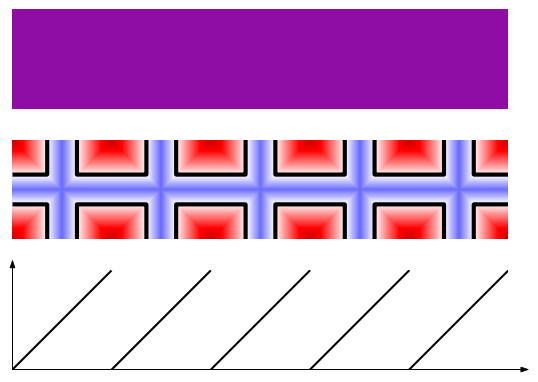

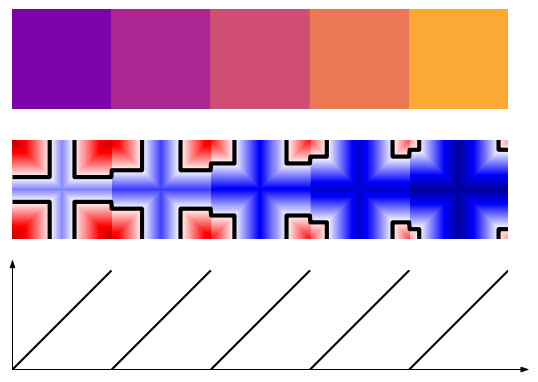

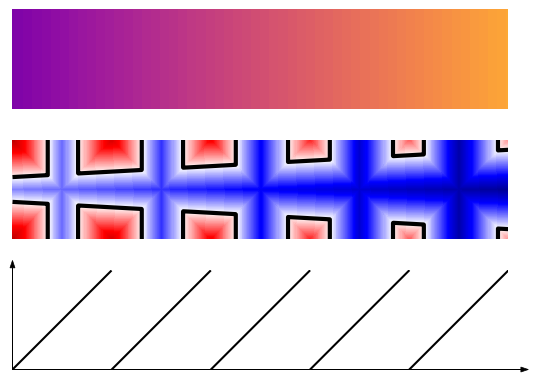

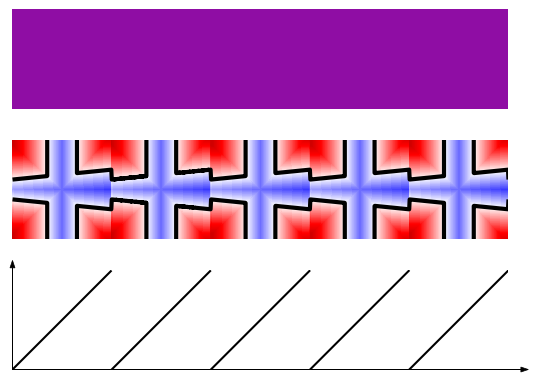

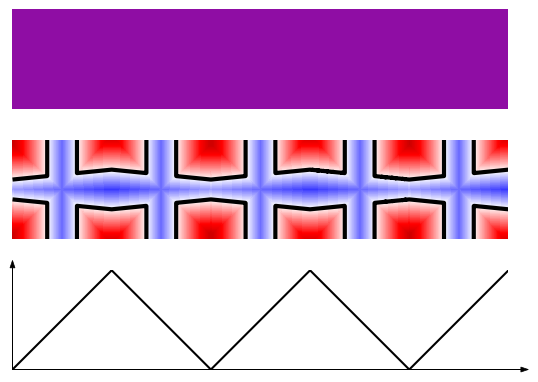

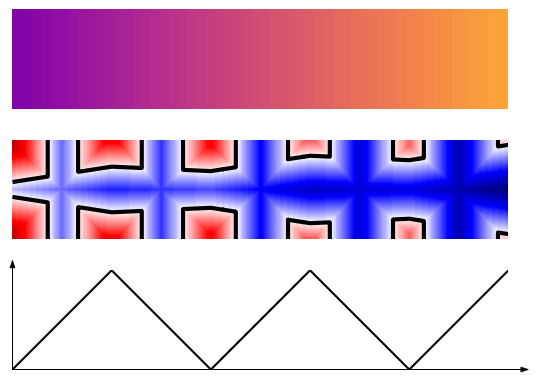

In [6]:
def plot_sdf_and_parameter(axes, sdf_type: str, para_type: str, flip: bool, clim_para, clim_sdf):
    avail_sdf_types = ["cylinders", "cones"]
    if sdf_type not in avail_sdf_types:
        raise RuntimeError(f"sdf_type must be one of {avail_sdf_types}")

    if sdf_type == "cylinders":
        sdf_fun = hor_beam_sdf_continuous
    if sdf_type == "cones":
        sdf_fun = hor_beam_sdf_discontinuous

    avail_para_types = ["const", "step", "linear"]
    if para_type not in avail_para_types:
        raise RuntimeError(f"paratype must be one of {avail_para_types}")

    
    X, Y = np.meshgrid(np.linspace(-1, 1, 1000), np.linspace(-1, 1, 1000))
    if para_type == "const":
        r = 0.3 + np.zeros_like(X)
    elif para_type == "step":
        orig_shape = X.shape
        r = discrete_interpolation.evaluate(X.reshape(-1,1)).reshape(X.shape)
    elif para_type == "linear":
        r = continuos_interpolation.evaluate(X.reshape(-1,1)).reshape(X.shape)

    transform_fun = transform_kof if flip else transform_chabra
    X_t = transform_fun(X, 5)

    Z = sdf_fun(np.array([X_t.flatten(), Y.flatten(), np.zeros(X.size)]).T, r.flatten(), r.flatten()).reshape(X.shape)

    max_r = clim_para[1]
    min_r = clim_para[0]
    # if i%2 != 0:
    #     X+=2
    #     x+=2
    # cbar = axes[2].contourf(flip_val*X+2, Y, Z_right, cmap="seismic", levels=np.linspace(-1,1,10))
    cbar = axes[1].contourf(X*5, Y, Z, cmap="seismic", levels=np.linspace(-1,1,100))
    # cbar.set_clim(-1,1)
    axes[1].contour(X*5, Y, Z, levels=[0], colors="black", linewidths=3)
    # axes[2].set_axis_off()

    axes[0].contourf(X*5, Y, r, levels=np.linspace(min_r,max_r,100), cmap="plasma")
    # axs[0,i//2].contourf(X, Y, flip*X, cmap="plasma")
    x = np.linspace(-1,1,1000)
    y = transform_fun(x, 5)# Split x into 5 equal parts
    split_indices = np.array_split(np.arange(len(x)), 5)

# Plot each part separately
    for indices in split_indices:
        axes[2].plot(x[indices][:-1] * 5, y[indices][:-1], "-k")

    axes[2].set_ylim([-1,1])
    axes[2].set_xlabel(r"$x$")
    axes[2].set_ylabel(r"$\hat{x}$")

    axes[2].arrow(-5, -1, 10.4, 0., fc='k', ec='k', lw=0.5, length_includes_head= True, clip_on = False, head_width=0.1, head_length=0.15)
    axes[2].arrow(-5, -1, 0., 2.2, fc='k', ec='k', lw=0.5, length_includes_head= True, clip_on = False, head_width=0.1, head_length=0.15)
    for ax in axes:
        ax.set_xlim(-5,5)
        ax.set_axis_off()
        ax.set_aspect(1)

clim_sdf = [-1,1]
clim_para = [0,1]
option_dicts = [
    {"sdf_type": "cylinders",
     "para_type": "const", 
     "flip": False, 
     "clim_para": clim_para, 
     "clim_sdf": clim_sdf},
    {"sdf_type": "cylinders",
     "para_type": "step", 
     "flip": False, 
     "clim_para": clim_para, 
     "clim_sdf": clim_sdf},
    {"sdf_type": "cylinders",
     "para_type": "linear", 
     "flip": False, 
     "clim_para": clim_para, 
     "clim_sdf": clim_sdf},
    {"sdf_type": "cones",
     "para_type": "const", 
     "flip": False, 
     "clim_para": clim_para, 
     "clim_sdf": clim_sdf},
    {"sdf_type": "cones",
     "para_type": "const", 
     "flip": True, 
     "clim_para": clim_para, 
     "clim_sdf": clim_sdf},
    {"sdf_type": "cones",
     "para_type": "linear", 
     "flip": True, 
     "clim_para": clim_para, 
     "clim_sdf": clim_sdf}
]

for i, option_dict in enumerate(option_dicts):
    fig, ax = plt.subplots(3,1)
    plot_sdf_and_parameter(ax, **option_dict)

    plt.savefig(f"evaluation_scripts/AICOMAS2024/plots/SDF_lattice_{i}.png", bbox_inches="tight", dpi=1000)

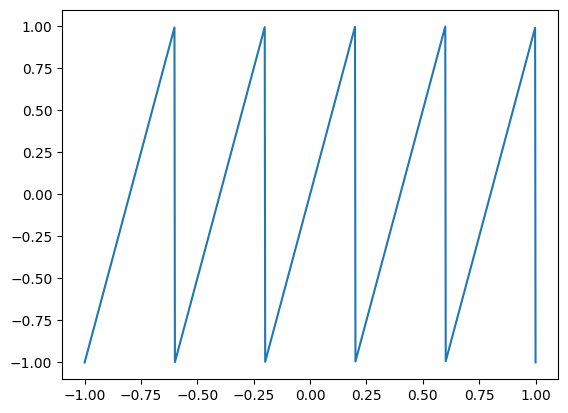

In [7]:
def transform_chabra(x, t):
    # t = t/2
    # x = x/t
    # x = (x+1)
    x = x + (t%2)*1/t
    t = t/2
    return (x-np.floor(x*t)/t)*t*2-1

x = np.linspace(-1,1,1000)
y = transform_chabra(x, 5)

plt.plot(x,y)